In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import sys
sys.path.append('./')
sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/')

from gls import datasets

import pandas as pd
import numpy as np

def load_sprint_trial_data(outcome='EVENT_PRIMARY'):
  assert outcome in ['EVENT_PRIMARY', 'EVENT_PRIMARYORDEATH'], "outcome can only be one of 'EVENT_PRIMARY' or 'EVENT_PRIMARY'"
  feature_list = {
    # demographic data
    'baseline.sas7bdat' : ['AGE', 'FEMALE', 'RACE4', 'SMOKE_3CAT', 'BMI', 'INTENSIVE',
                          'SBP', 'DBP', 'ASPIRIN', 'STATIN']
  }
  outcomes, features = datasets._load_generic_biolincc_dataset('outcomes.sas7bdat', 
                                                                   'T_PRIMARY', 'EVENT_PRIMARY',
                                                                   features=feature_list, 
                                                                   id_col='MASKID',
                                                                   location='datasets/SPRINT_POP/Datasets/')

  # Convert Censoring Indicator to Binary
  # ie. 1 = Event, 0 = Censored
  outcomes.event = outcomes.event == 1.0 
  
  NaNindex = pd.isna(outcomes.time)
  # print(len(NaNindex))
  # print(outcomes.loc[NaNindex])
  outcomes = outcomes.loc[~NaNindex]
  features = features.loc[~NaNindex]
  
  print(feature_list)

  features = features.rename(columns={"INTENSIVE": "Intervention", "AGE": "Age", "FEMALE": "Sex",
                          "RACE4": "Race", "SMOKE_3CAT": "Smoke", "SBP": "Systolic_Blood_Pressure",
                          "DBP": "Diastolic_Blood_Pressure", "ASPIRIN": "Daily_Aspirin_Use", 
                          "STATIN": "On_Statin"})

  features["Sex"] = np.where(features["Sex"] == 0.0, 'Male', 'Female')
  features['Intervention'] = np.where(features['Intervention'] == 0.0, 'SBP target <140 mm Hg', 'SBP target <120 mm Hg')
  features['Smoke'].replace({1.0: "Never", 2.0: "Former", 3.0: "Current", 4.0: "Missing"}, inplace=True)
  features['Daily_Aspirin_Use'] = np.where(features['Daily_Aspirin_Use'] == 0.0, 'No', 'Yes')
  features['On_Statin'] = np.where(features['On_Statin'] == 0.0, 'No', 'Yes')
   
  return outcomes, features

In [2]:
import pandas as pd
import torch
from tqdm import tqdm 
from examples.cmhe_demo_utils import * 

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the sprint dataset
outcomes, x = load_sprint_trial_data()

# Let's take a look at the dataset
x.head()

(9361, 10)
{'baseline.sas7bdat': ['AGE', 'FEMALE', 'RACE4', 'SMOKE_3CAT', 'BMI', 'INTENSIVE', 'SBP', 'DBP', 'ASPIRIN', 'STATIN']}


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\gls\datasets.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_40180\74102479.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outcomes.event = outcomes.event == 1.0


,Smoke,Age,Systolic_Blood_Pressure,Intervention,Race,Diastolic_Blood_Pressure,Daily_Aspirin_Use,Sex,BMI,On_Statin
S00007,Current,60.0,145.0,SBP target <140 mm Hg,WHITE,80.0,Yes,Male,33.115201,Yes
S00010,Former,75.0,138.0,SBP target <140 mm Hg,WHITE,71.0,Yes,Male,28.842380,Yes
S00022,Never,56.0,144.0,SBP target <120 mm Hg,HISPANIC,84.0,No,Female,24.888358,Yes
S00038,Former,62.0,143.0,SBP target <120 mm Hg,WHITE,92.0,No,Male,33.643060,No
S00045,Never,75.0,123.0,SBP target <140 mm Hg,WHITE,68.0,No,Female,29.337871,No


In [6]:
interventions = x['INTENSIVE']
interventions

S00007    0.0
S00010    0.0
S00022    1.0
S00038    1.0
S00045    0.0
         ... 
S99969    0.0
S99974    0.0
S99983    0.0
S99992    1.0
S99997    1.0
Name: INTENSIVE, Length: 9361, dtype: float64

In [6]:
from preprocessing import Preprocessor

cat_feats = ['RACE4', 'SMOKE_3CAT', 'FEMALE', 'INCLUSIONFRS', 'NOAGENTS', 'ASPIRIN',
            'SUB_CKD', 'RACE_BLACK', 'SUB_CVD', 'SUB_CLINICALCVD', 'SUB_SUBCLINICALCVD',
            'SUB_SENIOR', 'SBPTERTILE', 'STATIN', 'INTENSIVE']
num_feats = ['AGE', 'BMI', 'RISK10YRS', 'SBP', 'DBP', 'N_AGENTS', 'EGFR', 'SCREAT',
            'CHR', 'GLUR', 'HDL', 'TRR', 'UMALCR']

features = Preprocessor().fit_transform(x[cat_feats+num_feats], cat_feats=cat_feats, num_feats=num_feats)

In [7]:
features.head()

,AGE,BMI,RISK10YRS,SBP,DBP,N_AGENTS,EGFR,SCREAT,CHR,GLUR,...,SUB_CKD_1.0,RACE_BLACK_1.0,SUB_CVD_1.0,SUB_CLINICALCVD_1.0,SUB_SUBCLINICALCVD_1.0,SUB_SENIOR_1.0,SBPTERTILE_2.0,SBPTERTILE_3.0,STATIN_1.0,INTENSIVE_1.0
S00007,-0.840770,0.567923,0.891838,0.342168,0.156733,0.159574,-0.197156,0.104317,-0.854735,-1.317899,...,0,0,1,1,0,0,0,1,1,0
S00010,0.752309,-0.175767,0.886804,-0.107192,-0.596824,-0.803528,-0.540183,0.281514,1.287283,0.605608,...,0,0,0,0,0,1,1,0,1,0
S00022,-1.265591,-0.863970,-0.970130,0.277974,0.491647,1.122675,0.649462,-1.076998,1.019530,-0.282164,...,0,0,0,0,0,0,1,0,1,1
S00038,-0.628359,0.659798,-0.244520,0.213780,1.161475,0.159574,-0.160664,0.045251,-0.246207,1.271438,...,0,0,0,0,0,0,1,0,0,1
S00045,0.752309,-0.089526,-1.059779,-1.070106,-0.848010,0.159574,0.009633,-0.870268,1.068213,-0.430126,...,0,0,0,0,0,1,0,0,0,0


In [8]:
# Hyper-parameters to train model
k = 1 # number of underlying base survival phenotypes
g = 2 # number of underlying treatment effect phenotypes.
layers = [] # number of neurons in each hidden layer.

random_seed = 3
iters = 100 # number of training epochs
learning_rate = 0.001
batch_size = 256 
vsize = 0.15 # size of the validation split
patience = 5
optimizer = "Adam"
gate_l2_penalty = 1e-3

In [9]:
from sklearn.model_selection import train_test_split

# Split the data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(features, outcomes, test_size=0.5, random_state=1, stratify = outcomes.event + 2*interventions) 

print(f'Number of training data points: {len(x_train)}')
print(f'Number of test data points: {len(x_test)}')

Number of training data points: 4680
Number of test data points: 4681


In [10]:
x_tr = (x_train.loc[:, x_train.columns != 'INTENSIVE_1.0']).values.astype('float32')
t_tr = y_train['time'].values.astype('float32')
e_tr = y_train['event'].values.astype('float32')
a_tr = x_train['INTENSIVE_1.0'].values.astype('float32')

In [11]:
x_te = (x_test.loc[:, x_test.columns != 'INTENSIVE_1.0']).values.astype('float32')
t_te = y_test['time'].values.astype('float32')
e_te = y_test['event'].values.astype('float32')
a_te = x_test['INTENSIVE_1.0'].values.astype('float32')


In [12]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model
model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

model = model.fit(x_tr, t_tr, e_tr, a_tr, vsize=vsize, val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\models\cmhe\cmhe_utilities.py:121: RuntimeWarning: invalid value encountered in log
  probs.append(np.log(event_probs))
100%|██████████| 100/100 [00:25<00:00,  3.89it/s]


In [13]:
zeta_probs_train = model.predict_latent_phi(x_tr)
zeta_train =  np.argmax(zeta_probs_train, axis=1)
zeta_train

array([0, 0, 0, ..., 1, 1, 0], dtype=int64)

In [14]:
zeta_train.mean()

0.46153846153846156

In [15]:
zeta_probs_train

array([[0.7368839 , 0.26311615],
       [0.59231937, 0.4076807 ],
       [0.6846129 , 0.31538713],
       ...,
       [0.32613063, 0.67386943],
       [0.3409085 , 0.6590915 ],
       [0.62969726, 0.37030274]], dtype=float32)

In [16]:
idx_list_0 = np.where(zeta_train == 0)
idx_list_1 = np.where(zeta_train == 1)

In [17]:
from auton_survival import reporting
import matplotlib.pyplot as plt

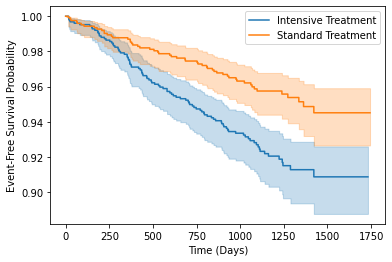

In [18]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax = reporting.plot_kaplanmeier(y_train.iloc[idx_list_0], x_train['INTENSIVE_1.0'].iloc[idx_list_0])
h, l = ax.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

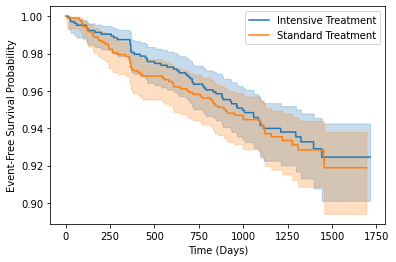

In [19]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax2 = reporting.plot_kaplanmeier(y_train.iloc[idx_list_1], x_train['INTENSIVE_1.0'].iloc[idx_list_1])
h, l = ax2.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

In [20]:
q = [0.9, 0.8, 0.7, 0.6]
zeta_train_qt = np.quantile(zeta_probs_train[:, 0], q)

In [21]:
idx_list_qt10 = np.where(zeta_probs_train[:, 0] >= zeta_train_qt[0])
idx_list_qt20 = np.where(zeta_probs_train[:, 0] >= zeta_train_qt[1])
idx_list_qt30 = np.where(zeta_probs_train[:, 0] >= zeta_train_qt[2])
idx_list_qt40 = np.where(zeta_probs_train[:, 0] >= zeta_train_qt[3])

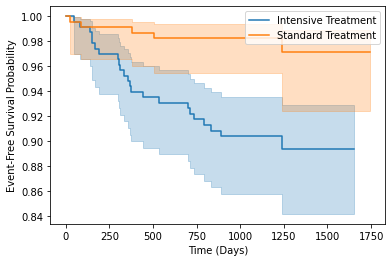

In [22]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax5 = reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt10], x_train['INTENSIVE_1.0'].iloc[idx_list_qt10])
h, l = ax5.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

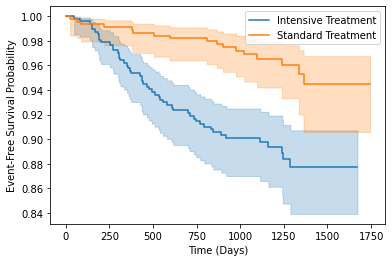

In [23]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax6 = reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt20], x_train['INTENSIVE_1.0'].iloc[idx_list_qt20])
h, l = ax6.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

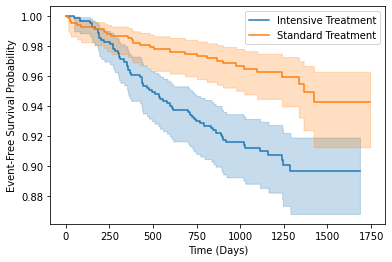

In [24]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax7 = reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt30], x_train['INTENSIVE_1.0'].iloc[idx_list_qt30])
h, l = ax7.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

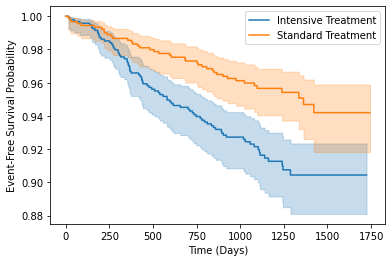

In [25]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax8 = reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt40], x_train['INTENSIVE_1.0'].iloc[idx_list_qt40])
h, l = ax8.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

In [26]:
zeta_probs_test = model.predict_latent_phi(x_te)
zeta_test =  np.argmax(zeta_probs_test, axis=1)
zeta_test

array([1, 1, 0, ..., 1, 0, 0], dtype=int64)

In [27]:
zeta_test.mean()

0.4466994232001709

In [28]:
idx_list_0te = np.where(zeta_test == 0)
idx_list_1te = np.where(zeta_test == 1)

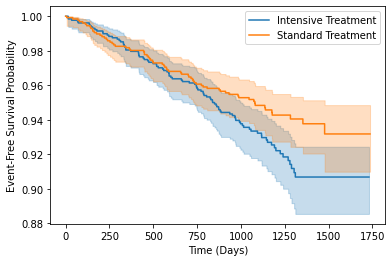

In [29]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax3 = reporting.plot_kaplanmeier(y_test.iloc[idx_list_0te], x_test['INTENSIVE_1.0'].iloc[idx_list_0te])
h, l = ax3.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

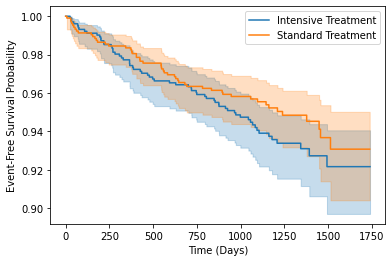

In [30]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax4 = reporting.plot_kaplanmeier(y_test.iloc[idx_list_1te], x_test['INTENSIVE_1.0'].iloc[idx_list_1te])
h, l = ax4.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

In [31]:
zeta_test_qt = np.quantile(zeta_probs_test[:, 0], q)

In [32]:
idx_list_qt10te = np.where(zeta_probs_test[:, 0] >= zeta_test_qt[0])
idx_list_qt20te = np.where(zeta_probs_test[:, 0] >= zeta_test_qt[1])
idx_list_qt30te = np.where(zeta_probs_test[:, 0] >= zeta_test_qt[2])
idx_list_qt40te = np.where(zeta_probs_test[:, 0] >= zeta_test_qt[3])

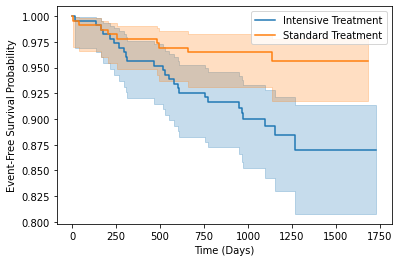

In [33]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax9 = reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt10te], x_test['INTENSIVE_1.0'].iloc[idx_list_qt10te])
h, l = ax9.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

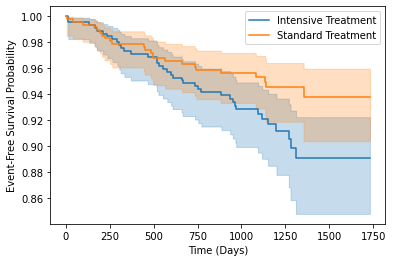

In [34]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax10 = reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt20te], x_test['INTENSIVE_1.0'].iloc[idx_list_qt20te])
h, l = ax10.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

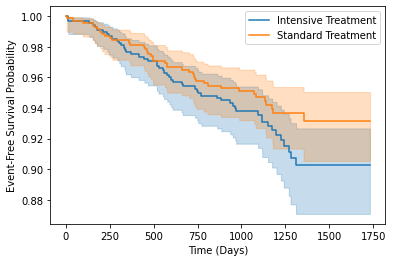

In [35]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax11 = reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt30te], x_test['INTENSIVE_1.0'].iloc[idx_list_qt30te])
h, l = ax11.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

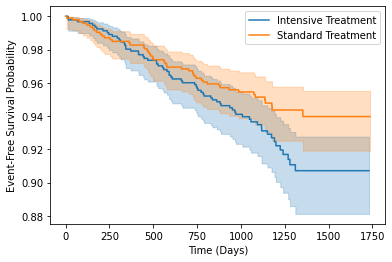

In [36]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax12 = reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt40te], x_test['INTENSIVE_1.0'].iloc[idx_list_qt40te])
h, l = ax12.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

In [37]:
# zeta 1
zeta_train_qt1 = np.quantile(zeta_probs_train[:, 1], q)
idx_list_qt10_1 = np.where(zeta_probs_train[:, 1] >= zeta_train_qt1[0])
idx_list_qt20_1 = np.where(zeta_probs_train[:, 1] >= zeta_train_qt1[1])
idx_list_qt30_1 = np.where(zeta_probs_train[:, 1] >= zeta_train_qt1[2])
idx_list_qt40_1 = np.where(zeta_probs_train[:, 1] >= zeta_train_qt1[3])

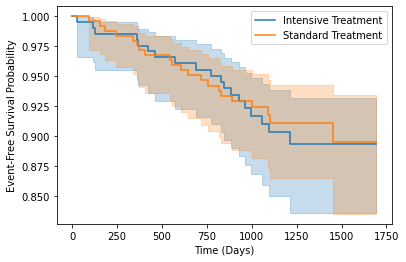

In [38]:
ax13 = reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt10_1], x_train['INTENSIVE_1.0'].iloc[idx_list_qt10_1])
h, l = ax13.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

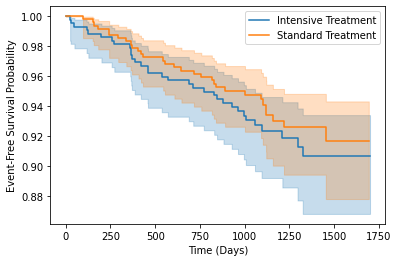

In [39]:
ax14 = reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt20_1], x_train['INTENSIVE_1.0'].iloc[idx_list_qt20_1])
h, l = ax14.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

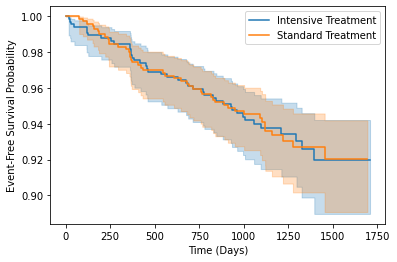

In [40]:
ax15 = reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt30_1], x_train['INTENSIVE_1.0'].iloc[idx_list_qt30_1])
h, l = ax15.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

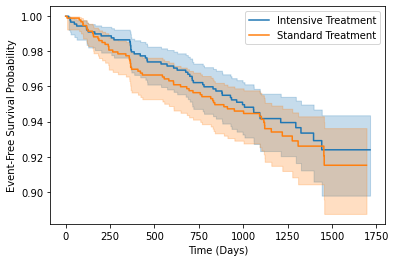

In [41]:
ax16 = reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt40_1], x_train['INTENSIVE_1.0'].iloc[idx_list_qt40_1])
h, l = ax16.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

In [42]:
# zeta 1
zeta_test_qt1 = np.quantile(zeta_probs_test[:, 1], q)
idx_list_qt10te_1 = np.where(zeta_probs_test[:, 1] >= zeta_test_qt1[0])
idx_list_qt20te_1 = np.where(zeta_probs_test[:, 1] >= zeta_test_qt1[1])
idx_list_qt30te_1 = np.where(zeta_probs_test[:, 1] >= zeta_test_qt1[2])
idx_list_qt40te_1 = np.where(zeta_probs_test[:, 1] >= zeta_test_qt1[3])

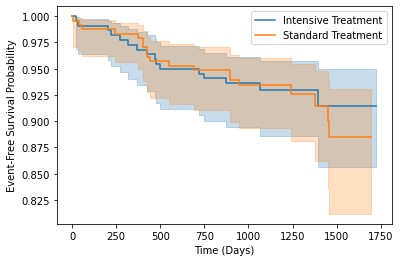

In [43]:
ax17 = reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt10te_1], x_test['INTENSIVE_1.0'].iloc[idx_list_qt10te_1])
h, l = ax17.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

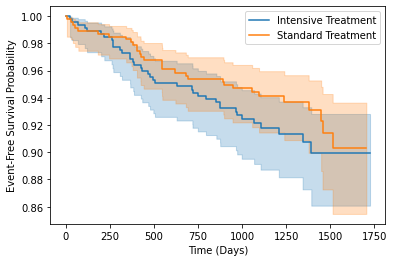

In [44]:
ax18 = reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt20te_1], x_test['INTENSIVE_1.0'].iloc[idx_list_qt20te_1])
h, l = ax18.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

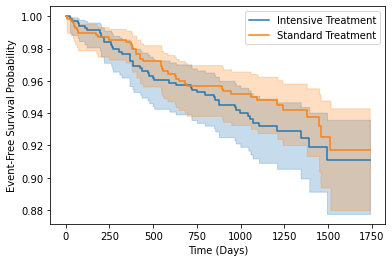

In [45]:
ax19 = reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt30te_1], x_test['INTENSIVE_1.0'].iloc[idx_list_qt30te_1])
h, l = ax19.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

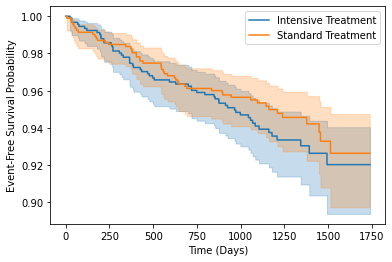

In [46]:
ax20 = reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt40te_1], x_test['INTENSIVE_1.0'].iloc[idx_list_qt40te_1])
h, l = ax20.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

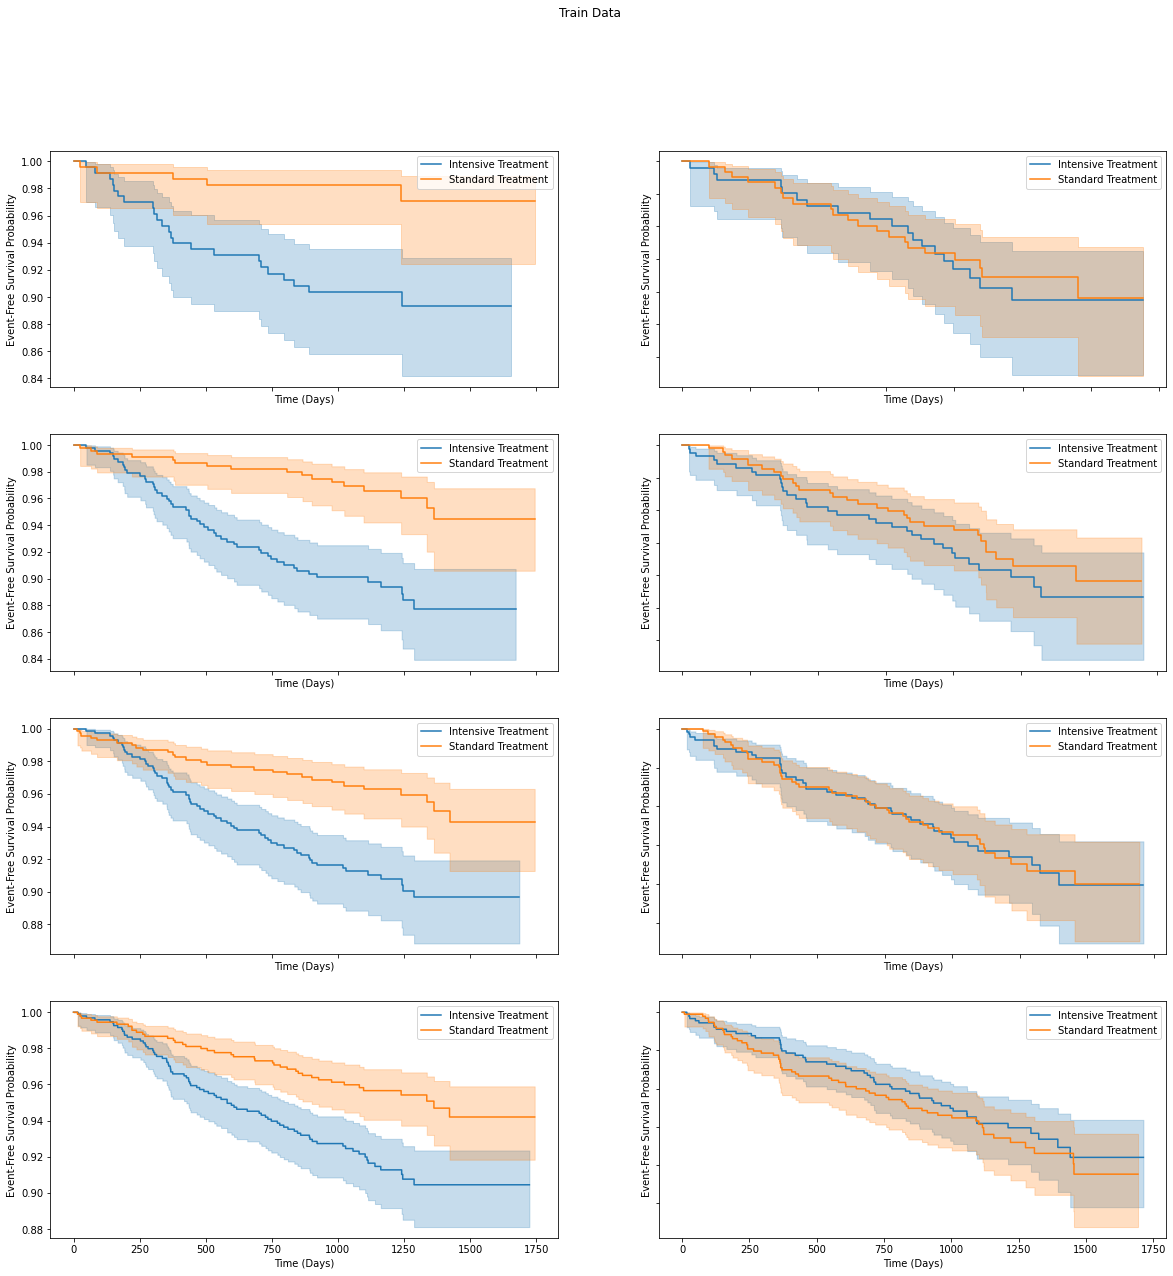

In [69]:
fig, ((ax5, ax13), (ax6, ax14), (ax7, ax15), (ax8, ax16)) = plt.subplots(4, 2, figsize= (20, 20))
fig.suptitle('Train Data')
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt10], x_train['INTENSIVE_1.0'].iloc[idx_list_qt10], ax=ax5)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt20], x_train['INTENSIVE_1.0'].iloc[idx_list_qt20], ax=ax6)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt30], x_train['INTENSIVE_1.0'].iloc[idx_list_qt30], ax=ax7) 
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt40], x_train['INTENSIVE_1.0'].iloc[idx_list_qt40], ax=ax8)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt10_1], x_train['INTENSIVE_1.0'].iloc[idx_list_qt10_1], ax=ax13)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt20_1], x_train['INTENSIVE_1.0'].iloc[idx_list_qt20_1], ax=ax14)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt30_1], x_train['INTENSIVE_1.0'].iloc[idx_list_qt30_1], ax=ax15)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt40_1], x_train['INTENSIVE_1.0'].iloc[idx_list_qt40_1], ax=ax16) 
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

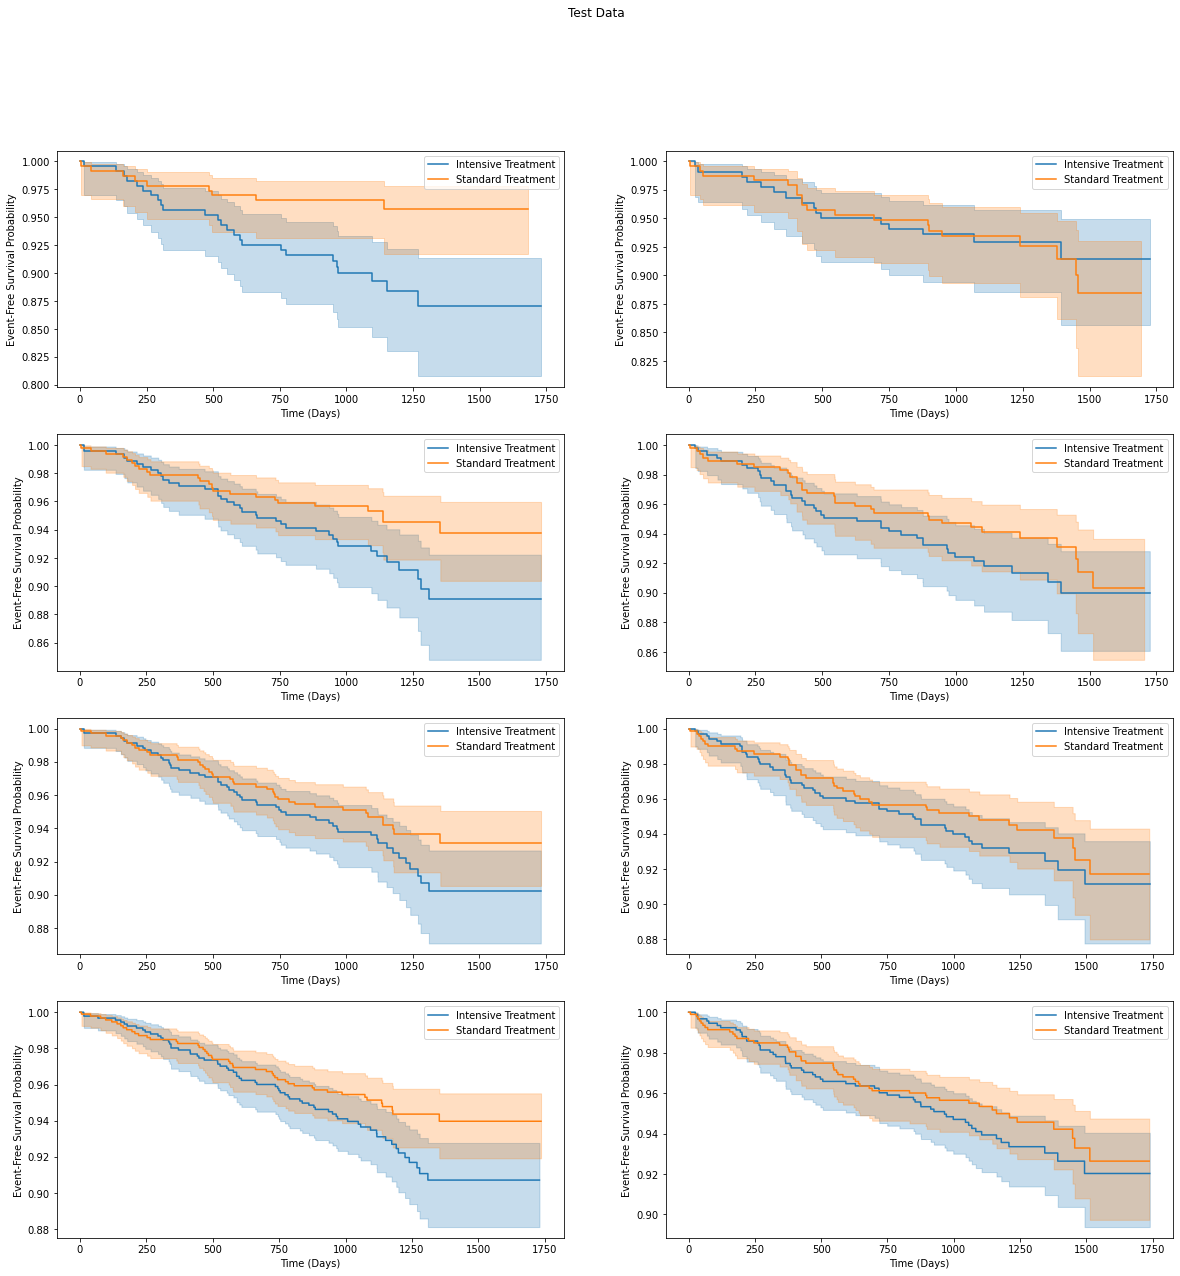

In [71]:
fig, ((ax9, ax17), (ax10, ax18), (ax11, ax19), (ax12, ax20)) = plt.subplots(4, 2, figsize= (20, 20))
fig.suptitle('Test Data')
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt10te], x_test['INTENSIVE_1.0'].iloc[idx_list_qt10te], ax=ax9)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt20te], x_test['INTENSIVE_1.0'].iloc[idx_list_qt20te], ax=ax10)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt30te], x_test['INTENSIVE_1.0'].iloc[idx_list_qt30te], ax=ax11)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt40te], x_test['INTENSIVE_1.0'].iloc[idx_list_qt40te], ax=ax12)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt10te_1], x_test['INTENSIVE_1.0'].iloc[idx_list_qt10te_1], ax=ax17)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt20te_1], x_test['INTENSIVE_1.0'].iloc[idx_list_qt20te_1], ax=ax18)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt30te_1], x_test['INTENSIVE_1.0'].iloc[idx_list_qt30te_1], ax=ax19)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt40te_1], x_test['INTENSIVE_1.0'].iloc[idx_list_qt40te_1], ax=ax20)
for ax in fig.get_axes():
    # ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()